<a href="https://colab.research.google.com/github/suirin1/ds-practice01/blob/main/%E7%B5%B1%E8%A8%88%E5%AD%A6%E5%85%A5%E9%96%80_kadai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   体重
0  48
1  44
2  48
3  52
4  58
      階級  度数
0  35-49   1
1  40-44   8
2  45-49  29
3  50-54  23
4  55-59  11
5  60-64   6
6  65-69   2


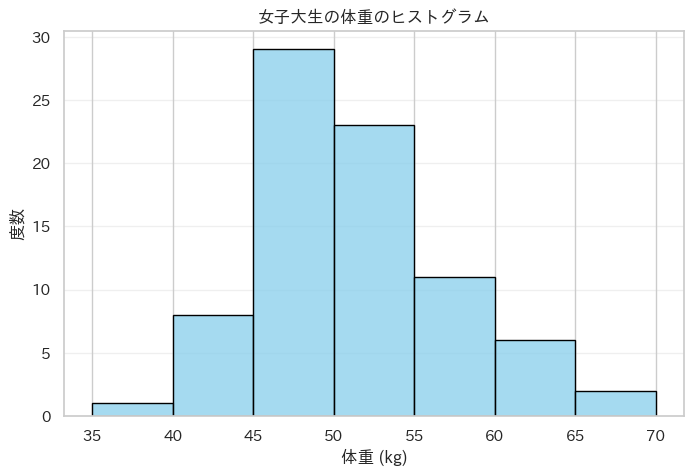

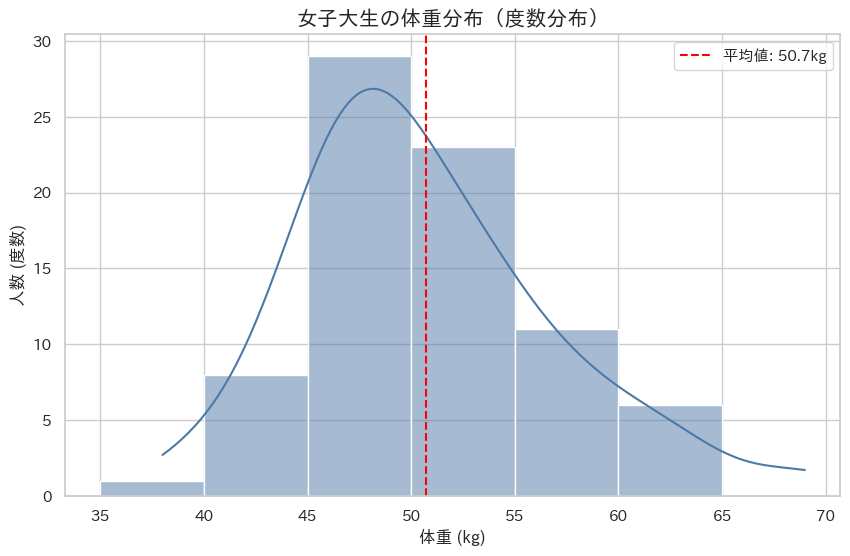

In [7]:
#p23 練習問題
#女子大生の体重について、①度数分布表を作る　②ヒストグラムを描く
#dataはdata_female_weight.csvを使用する

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 日本語表示の設定（Colabで豆腐文字を防ぐ）
!pip install japanize-matplotlib
import japanize_matplotlib

# ファイル名だけで読み込めます（/content/ 直下にdataをおくため）
df = pd.read_csv('data_female_weight.csv', header=0, names=['体重'])

# 中身を確認
print(df.head())

# 2. 階級の幅を決める（例：35kgから70kgまで5kg刻み）
bins = [35, 40, 45, 50, 55, 60, 65, 70]
labels = ["35-49", "40-44", "45-49", "50-54", "55-59", "60-64", "65-69"]

# 階級ごとにカット
df['階級'] = pd.cut(df['体重'], bins=bins, labels=labels, right=False)

# 度数分布表の作成
frequency_table = df['階級'].value_counts().sort_index().reset_index()
frequency_table.columns = ['階級', '度数']

# 表の表示
print(frequency_table)

# 3. ヒストグラムの描画
plt.figure(figsize=(8, 5))
sns.histplot(df['体重'], bins=bins, kde=False, color='skyblue', edgecolor='black')

plt.title('女子大生の体重のヒストグラム')
plt.xlabel('体重 (kg)')
plt.ylabel('度数')
plt.grid(axis='y', alpha=0.3)
plt.show()

#グラフをより整えてみる

import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib

# グラフのスタイル設定
sns.set_theme(font='IPAexGothic', style='whitegrid') # 綺麗めなスタイル
plt.figure(figsize=(10, 6))

# ヒストグラムの描画
# binsは度数分布表に合わせた設定にします
sns.histplot(df['体重'], bins=range(35, 70, 5), kde=True, color='#4e79a7', edgecolor='white')

# ラベルとタイトルの設定
plt.title('女子大生の体重分布（度数分布）', fontsize=15)
plt.xlabel('体重 (kg)', fontsize=12)
plt.ylabel('人数 (度数)', fontsize=12)

# 平均値を線で引いてみる
plt.axvline(df['体重'].mean(), color='red', linestyle='--', label=f'平均値: {df["体重"].mean():.1f}kg')
plt.legend()

plt.show()